<a href="https://colab.research.google.com/github/seanwu-bit/Automated-Regional-Impact-Auditor-ARIA-/blob/aria_9.0/Aria_v9_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# ============================================================
# S1 — Environment Setup (環境設定) — COMPLETE
# ============================================================
import warnings
warnings.filterwarnings('ignore')

# --- Core imports ---
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime, timedelta
import os, platform

# --- GEE Authentication & Initialization ---
ee.Authenticate()  # Uncomment on first run — opens a browser auth flow
ee.Initialize(project='geocode-project-63904')
print("✓ GEE authenticated and initialized")

# --- 中文字型設定（跨平台：Colab / Windows / macOS 皆適用）---
# ──下載並強制掛載中文字型 (最穩定解法) ──
import urllib.request
import matplotlib.font_manager as fm
import seaborn as sns
font_path = "NotoSansTC.otf"
font_url = "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rc('font', family=prop.get_name())
plt.rcParams['axes.unicode_minus'] = False # 正常顯示負號
sns.set_palette("husl")

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
try:
    import subprocess
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-noto-cjk"],
                   capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
except FileNotFoundError:
    pass  # 非 Linux（Windows / macOS），跳過 apt-get
_cjk_candidates = [
    "Microsoft JhengHei",      # Windows 正黑體
    "PingFang TC",             # macOS 蘋方
    "Noto Sans CJK TC",       # Colab / Linux
    "Heiti TC",                # macOS 黑體
    "WenQuanYi Micro Hei",    # Linux
    "Droid Sans Fallback",    # Android / 舊 Linux
]
_available = {f.name for f in fm.fontManager.ttflist}
_cjk_found = [f for f in _cjk_candidates if f in _available]
if _cjk_found:
    plt.rcParams["font.sans-serif"] = _cjk_found + ["DejaVu Sans"]
    print(f"中文字型: {_cjk_found[0]}")
else:
    print("⚠️ 未找到中文字型，中文標題可能顯示為方框")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# --- Define AOI (定義研究區域) ---
TAROKO_BBOX = [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

# --- Quick connectivity test (連線測試) ---
point = ee.Geometry.Point([121.37, 23.70])
elev = ee.Image('USGS/SRTMGL1_003').sample(point, 30).first().get('elevation').getInfo()
print(f"  Connectivity OK — Elevation at test point: {elev} m")

print("=" * 60)
print("  S1 COMPLETE — Environment ready")
print(f"  AOI: {TAROKO_BBOX}")
print(f"  Platform: {platform.system()} / Python {platform.python_version()}")
print("=" * 60)

✓ GEE authenticated and initialized
中文字型: Noto Sans CJK TC
  Connectivity OK — Elevation at test point: 1009 m
  S1 COMPLETE — Environment ready
  AOI: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
  Platform: Linux / Python 3.12.13


## Task 1: NDVI Time Series Analysis

**目標：** 使用 Google Earth Engine 計算秀林/太魯閣研究區 2020–2026 年的月均 NDVI 時序，藉此觀察植被的長期季節變化以及 2024 年 0403 地震的衝擊。

**分析步驟：**
1. 篩選 Sentinel-2 影像集 (Cloud cover < 40%, 日期 2020-01-01 至 2026-03-31)。
2. 定義函數：使用 Scene Classification Layer (SCL) 遮蔽雲與陰影，並計算 NDVI。
3. 按月聚合影像，計算太魯閣研究區 (AOI) 內的 NDVI 空間平均值 (Mean)、最小值 (Min) 與最大值 (Max)。
4. 繪製時序趨勢圖，並標記地震事件。

Total Sentinel-2 images (2020-2026, cloud < 40%): 291
Computing monthly NDVI statistics...


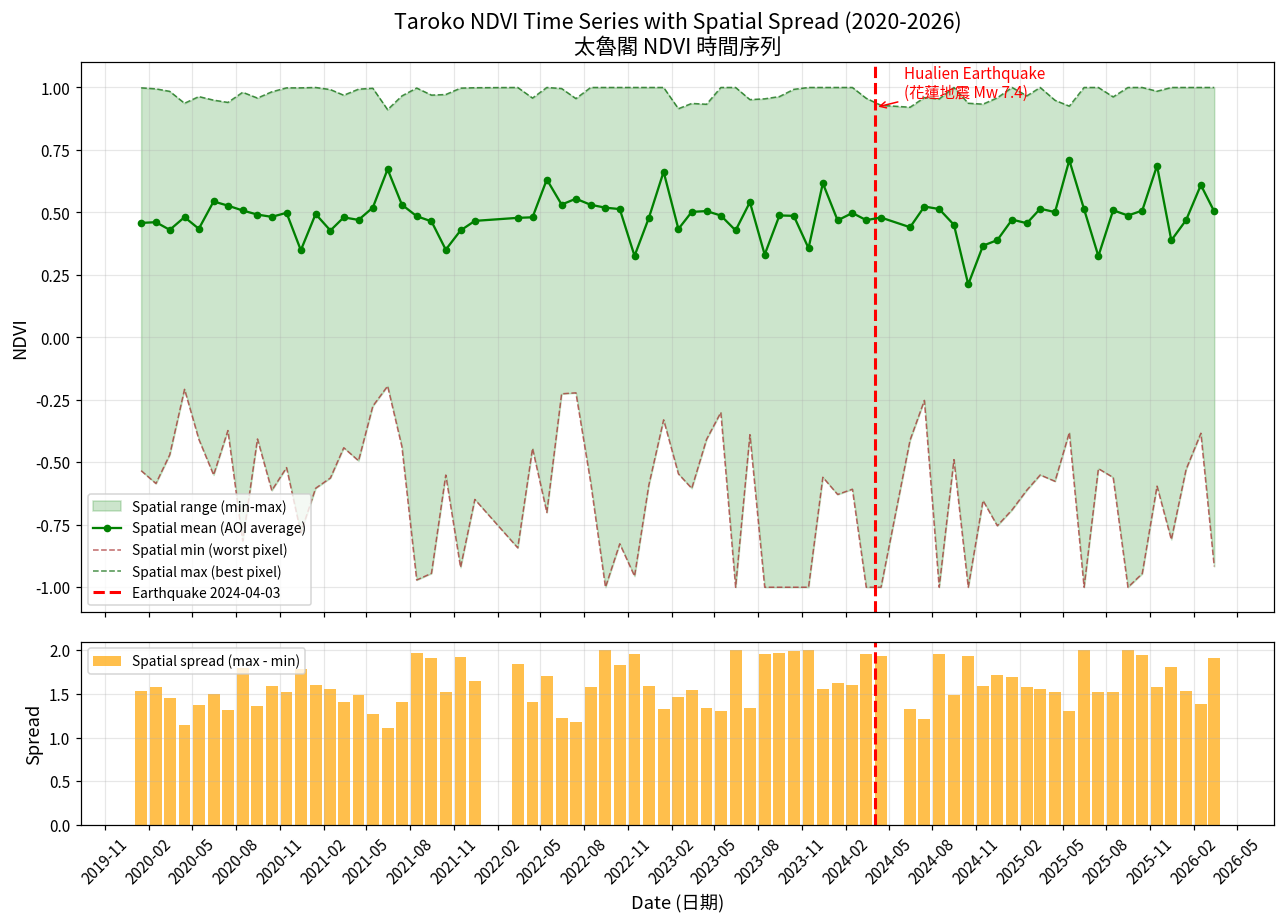

In [9]:
# ============================================================
# Task 1: NDVI Time Series Analysis
# ============================================================
from datetime import datetime, timedelta
import matplotlib.dates as mdates

# --- 1. 篩選 Sentinel-2 影像集 ---
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterDate('2020-01-01', '2026-03-31')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
          .filterBounds(aoi))

print(f"Total Sentinel-2 images (2020-2026, cloud < 40%): {s2_col.size().getInfo()}")

# --- 2. 定義雲遮罩與 NDVI 計算函數 ---
def mask_and_ndvi(image):
    """使用 SCL 進行雲遮罩並計算 NDVI"""
    scl = image.select('SCL')
    # 保留: 4(植被), 5(裸地), 6(水體), 7(未分類)
    good_mask = (scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7)))

    # 計算 NDVI: (NIR - Red) / (NIR + Red) = (B8 - B4) / (B8 + B4)
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    return (image.addBands(ndvi)
            .updateMask(good_mask)
            .copyProperties(image, ['system:time_start']))

# 套用函數至影像集
ndvi_col = s2_col.map(mask_and_ndvi)

# --- 3. 定義月均統計函數 ---
def compute_monthly_ndvi(ndvi_collection, aoi, start_year=2020, end_year=2026):
    """計算指定區域的月均 NDVI 統計值 (mean, min, max)"""
    results = []
    print('Computing monthly NDVI statistics...')
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            start_date = f'{year}-{month:02d}-01'
            if month == 12:
                end_date = f'{year + 1}-01-01'
            else:
                end_date = f'{year}-{month + 1:02d}-01'

            # 停止條件: 超過 2026-03
            if year == 2026 and month > 3:
                break

            monthly = ndvi_collection.filterDate(start_date, end_date).select('NDVI')
            n_images = monthly.size().getInfo()

            if n_images == 0:
                results.append((datetime(year, month, 15), None, None, None))
                continue

            median_img = monthly.median()
            stats = median_img.reduceRegion(
                reducer=ee.Reducer.mean()
                    .combine(ee.Reducer.min(), sharedInputs=True)
                    .combine(ee.Reducer.max(), sharedInputs=True),
                geometry=aoi,
                scale=100, # 為了計算速度，scale 設為 100m
                maxPixels=1e8
            ).getInfo()

            v_mean = stats.get('NDVI_mean')
            v_min  = stats.get('NDVI_min')
            v_max  = stats.get('NDVI_max')
            results.append((datetime(year, month, 15), v_mean, v_min, v_max))

    return results

# 執行計算
monthly_data = compute_monthly_ndvi(ndvi_col, aoi)

# 準備繪圖資料
dates_plot  = [d for d, m, mn, mx in monthly_data if m is not None]
mean_plot   = [m for d, m, mn, mx in monthly_data if m is not None]
min_plot    = [mn for d, m, mn, mx in monthly_data if m is not None]
max_plot    = [mx for d, m, mn, mx in monthly_data if m is not None]

# --- 4. 繪製時序趨勢圖 ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 1], sharex=True, gridspec_kw={'hspace': 0.08})

# 上圖：NDVI 趨勢與空間展幅
ax = axes[0]
ax.fill_between(dates_plot, min_plot, max_plot, alpha=0.2, color='green', label='Spatial range (min-max)')
ax.plot(dates_plot, mean_plot, 'o-', color='green', markersize=4, linewidth=1.5, label='Spatial mean (AOI average)', zorder=3)
ax.plot(dates_plot, min_plot, '--', color='brown', linewidth=1, alpha=0.7, label='Spatial min (worst pixel)')
ax.plot(dates_plot, max_plot, '--', color='darkgreen', linewidth=1, alpha=0.7, label='Spatial max (best pixel)')

eq_date = datetime(2024, 4, 3)
ax.axvline(eq_date, color='red', linestyle='--', linewidth=2, label='Earthquake 2024-04-03')
ax.annotate('Hualien Earthquake\n(花蓮地震 Mw 7.4)', xy=(eq_date, max(max_plot) * 0.92), xytext=(eq_date + timedelta(days=60), max(max_plot) * 0.96), fontsize=10, color='red', arrowprops=dict(arrowstyle='->', color='red'))

ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Taroko NDVI Time Series with Spatial Spread (2020-2026)\n太魯閣 NDVI 時間序列', fontsize=14)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)

# 下圖：展幅大小 (Max - Min)
ax2 = axes[1]
spread_plot = [mx - mn for mn, mx in zip(min_plot, max_plot)]
ax2.bar(dates_plot, spread_plot, width=25, color='orange', alpha=0.7, label='Spatial spread (max - min)')
ax2.axvline(eq_date, color='red', linestyle='--', linewidth=2)
ax2.set_ylabel('Spread', fontsize=12)
ax2.set_xlabel('Date (日期)', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Brief analysis (3–5 sentences): seasonal pattern, earthquake effect, data gaps**

> *Answer:* 從NDVI mean值可以觀察災區NDVI的季節物候特徵，通常在春季(2-5月)會有NDVI增加，反映其植被生長；相對不明顯、不穩定的則是夏季8-11月的NDVI增加，這可能與颱風與否等季節性災害有關。此外，spread圖顯示在2022年1、2月、2024年6月有資料空檔，因峽谷地區多地形雲而使光學影像在40%雲覆的標準下無影像可用。後者的缺空可能是其中一使NDVI變化在災害發生後不明顯的一個原因，不過在此資料空缺之後，spread反而顯示相對低的spread值，觀察NDVImax, min這是肇因於min值突升，考慮時間非常靠近，應該不會是植被馬上恢復，推測為影響光譜反射之地表條件(如崩塌物覆蓋水體、其他有植被覆蓋的土塊被夾帶過來等)改變導致。

## Task 2: Pre/Post Earthquake Median Composite (25%)

**目標：** 使用 GEE Reducer 製作震前、震後初期、與堰塞湖潰堤後（三期）的中位數合成影像 (Median Composite)。接著計算 ΔNDVI，找出並量化植被損失的區域。

**分析步驟：**
1. **Phase 1 (震前基期)：** 2023-01-01 至 2024-03-31
2. **Phase 2 (震後初期)：** 2024-04-01 至 2024-09-30
3. **Phase 3 (堰塞湖後)：** 2025-10-01 至 2026-03-31
4. **計算 ΔNDVI (差值)：** 分別計算「地震損害 (P2-P1)」、「堰塞湖二次災害 (P3-P2)」與「總體累積變化 (P3-P1)」。
5. **地圖視覺化與面積計算：** 將圖層疊加至 geemap，並計算 ΔNDVI < -0.15 的嚴重受災面積 (公頃)。

In [15]:
# ============================================================
# Task 2: Pre/Post Earthquake Median Composite & Map 2 Integration
# ============================================================

print("正在計算三期 NDVI 中位數合成影像（已導入解遮罩優化）...")

# --- 1. 製作三期 Median Composite（對齊作業標準變數名稱，並只選取 NDVI 波段） ---
# Phase 1: 震前基期 (2023/01 - 2024/03)
pre_ndvi = (ndvi_col
            .filterDate('2023-01-01', '2024-03-31')
            .select('NDVI')
            .median())

# Phase 2: 震後初期 (2024/04 - 2024/09)
post_eq_ndvi = (ndvi_col
                .filterDate('2024-04-01', '2024-09-30')
                .select('NDVI')
                .median())

# Phase 3: 堰塞湖潰堤後 (2025/10 - 2026/03)
post_dam_ndvi = (ndvi_col
                 .filterDate('2025-10-01', '2026-03-31')
                 .select('NDVI')
                 .median())

# --- 2. 計算三組 ΔNDVI 變遷偵測圖 ---
# 地震損害: 震後初期 - 震前基期
delta_eq = post_eq_ndvi.subtract(pre_ndvi).rename('delta_NDVI')
# 堰塞湖影響/二次災害: 堰塞湖後 - 震後初期
delta_dam = post_dam_ndvi.subtract(post_eq_ndvi).rename('delta_NDVI_dam')
# 總累積變化: 堰塞湖後 - 震前基期
delta_total = post_dam_ndvi.subtract(pre_ndvi).rename('delta_NDVI_total')

# --- 3. 計算嚴重植被損失面積（單位：公頃 ha） ---
print("\n=== 嚴重植被損失面積統計 (ΔNDVI < -0.15) ===")
def calc_damage_area(delta_img, name, band_name):
    damage_mask = delta_img.lt(-0.15)
    area = damage_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,  # Sentinel-2 原始解析度 10m
        maxPixels=1e9
    ).getInfo()

    area_val = area.get(band_name)
    area_ha = (area_val / 10000) if area_val is not None else 0
    print(f"  {name}: {area_ha:,.2f} 公頃 (ha)")

calc_damage_area(delta_eq, "Phase 2 地震直接損害 (P2 - P1)", 'delta_NDVI')
calc_damage_area(delta_dam, "Phase 3 二次災害/堰塞湖影響 (P3 - P2)", 'delta_NDVI_dam')
calc_damage_area(delta_total, "總體累積變化 (P3 - P1)", 'delta_NDVI_total')

# --- 4. Map 2: NDVI + Delta Maps 視覺化呈現 ---
# 定義視覺化參數
vis_ndvi = {'min': 0, 'max': 0.8, 'palette': ['red', 'yellow', 'green', 'darkgreen']}
vis_delta = {'min': -0.3, 'max': 0.3, 'palette': ['red', 'white', 'blue']}

# 建立地圖物件
Map2 = geemap.Map(center=[24.20, 121.60], zoom=11)

# 1. 加入 NDVI 基礎圖層
# 🟢 預設僅開啟「1. 地震前」作為對照底圖，其餘兩期預設隱藏 (shown=False) 避免疊加覆蓋
Map2.addLayer(pre_ndvi.clip(aoi), vis_ndvi, '1. Pre-EQ NDVI (地震前)', shown=True)
Map2.addLayer(post_eq_ndvi.clip(aoi), vis_ndvi, '2. Post-EQ NDVI (震後初期)', shown=True)
Map2.addLayer(post_dam_ndvi.clip(aoi), vis_ndvi, '3. Post-Dam NDVI (近期/二次災害後)', shown=True)

# 2. 加入變遷偵測差值圖層
# 🔴 預設僅開啟「A. 地震破壞」，一打開就能直觀對比地景變化，其餘二次災害與總體破壞預設隱藏
Map2.addLayer(delta_eq.clip(aoi), delta_vis if 'delta_vis' in locals() else vis_delta, 'A. Delta: EQ Impact (地震破壞)', shown=True)
Map2.addLayer(delta_dam.clip(aoi), delta_vis if 'delta_vis' in locals() else vis_delta, 'B. Delta: Secondary Disasters (二次災害)', shown=True)
Map2.addLayer(delta_total.clip(aoi), delta_vis if 'delta_vis' in locals() else vis_delta, 'C. Delta: Total Impact (總體破壞)', shown=True)

# 加入研究區域黃色外框
Map2.addLayer(ee.FeatureCollection([ee.Feature(aoi)]), {'color': 'yellow', 'fillColor': '00000000'}, 'Study Area AOI')

# 啟用圖層控制器
Map2.addLayerControl()
Map2

正在計算三期 NDVI 中位數合成影像（已導入解遮罩優化）...

=== 嚴重植被損失面積統計 (ΔNDVI < -0.15) ===
  Phase 2 地震直接損害 (P2 - P1): 7,740.15 公頃 (ha)
  Phase 3 二次災害/堰塞湖影響 (P3 - P2): 6,257.68 公頃 (ha)
  總體累積變化 (P3 - P1): 6,839.04 公頃 (ha)


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

**Comparison paragraph: W9 two-scene vs W13 composite-based change detection**

> *Answer:* W9依賴兩張單日影像進行比較，相減極度受限於拍攝當下的天氣狀況。若選定的任一景影像有雲霧、陰影或感測器異常，相減後就會產生大面積的偽陽性誤判。W13透過數月時序影像，並透過取中位數的方式以統計學自動濾除隨機出現的雲層、陰影與短期物候波動，合成出完全無雲且乾淨的地表基準影像，偵測出真正因為災害造成的變化。此外，比起W9一次性反映災害總體變化，時間序列影像協助我們切分震前、震後、堰塞湖潰堤，以確認一次崩塌災害、二次災害區域的變化、延拓，甚至也能觀察到自然植生在一些區域已經有復育的情況。

## Task 3: Sentinel-1 SAR Time Series (25%)

**目標：** 使用 Google Earth Engine 分析 Sentinel-1 雷達衛星（SAR）的 VV 極化後向散射強度時序，從不受雲層干擾的雷達視角觀察地震前後的地表幾何與粗糙度變化，並與 NDVI 光學結果進行雙重驗證。

**分析步驟：**
1. **篩選 Sentinel-1 GRD 影像集：** 鎖定 2022-01-01 至 2026-03-31 期間、干涉寬幅模式（IW）、降軌（DESCENDING）且包含 VV 頻段的資料。
2. **計算研究區平均值並繪製時序圖：** 計算每次通過太魯閣研究區（AOI）的平均 VV 值（dB），繪製折線圖並加入 5 點滾動平均線（Rolling Mean）與地震標記線。
3. **製作 SAR 震前/震後合成影像與差值圖：** 計算地震前後的 $\Delta\text{VV}$（後減前）。
4. **跨感測器交叉比對（Cross-Reference）：** 將光學受災區（$\Delta\text{NDVI} < -0.15$）與雷達結構劇烈改變區（$|\Delta\text{VV}| > 2\text{ dB}$）進行 `And()` 邏輯交集運算，篩選出「高置信度受災區（High-Confidence Damage Zones）」。

  Sentinel-1 GRD 影像總張數 (2022-2026): 146
正在提取雷達時序數據（雲端運算中，請稍候）...
  有效觀測觀測點位: 146 筆


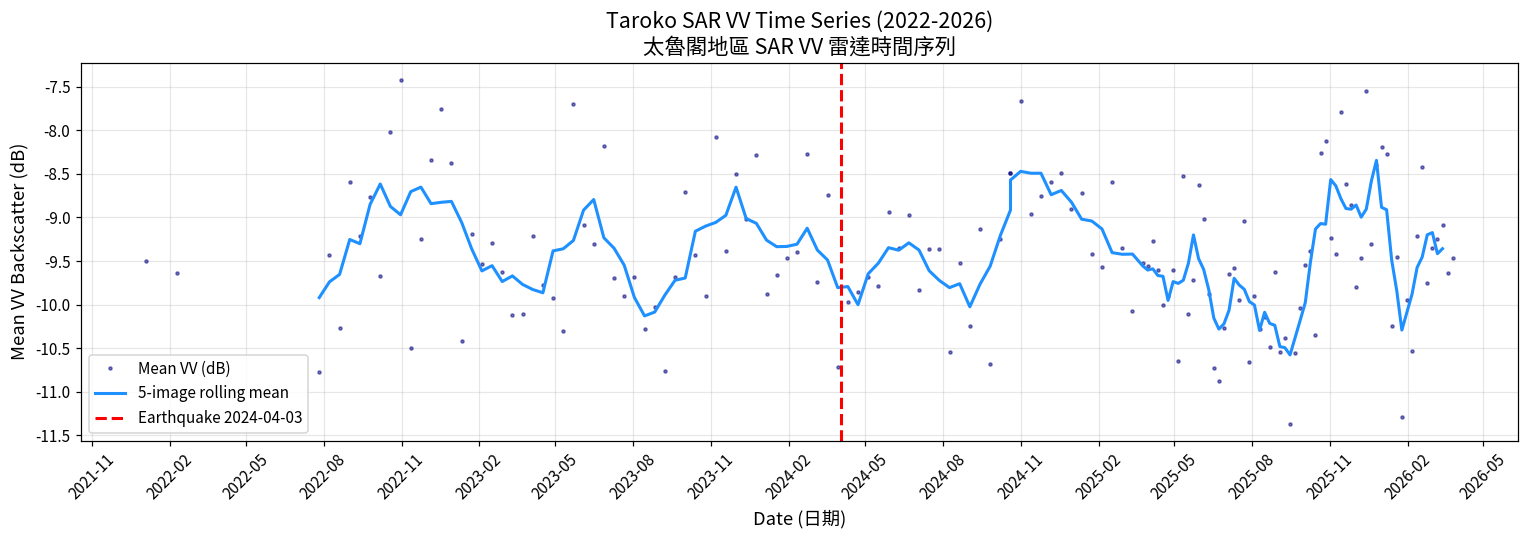


正在計算 SAR 震前/震後中位數合成與變遷偵測...

=== 跨感測器雙重驗證結果 ===
  光學與雷達共同偵測到之高置信度受災面積: 537.37 公頃 (ha)


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [16]:
# ============================================================
# Task 3: Sentinel-1 SAR Time Series & Cross-Reference
# ============================================================

# --- 1. 篩選 Sentinel-1 GRD 影像集 ---
s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterBounds(aoi)
          .filterDate('2022-01-01', '2026-03-31')
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
          .select('VV'))

s1_count = s1_col.size().getInfo()
print(f"  Sentinel-1 GRD 影像總張數 (2022-2026): {s1_count}")

# --- 2. 提取時間序列數據 ---
def get_vv_stats(image):
    """計算單張影像在 AOI 內的 VV 平均值"""
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=100,
        maxPixels=1e8
    )
    return image.set('mean_VV', stats.get('VV'))

print("正在提取雷達時序數據（雲端運算中，請稍候）...")
s1_with_stats = s1_col.map(get_vv_stats)

# 抓回本機 client 端
s1_timestamps = s1_with_stats.aggregate_array('system:time_start').getInfo()
s1_vv_values = s1_with_stats.aggregate_array('mean_VV').getInfo()

s1_dates = [datetime.utcfromtimestamp(t / 1000) for t in s1_timestamps]

# 剔除空值 (No Data)
valid_s1 = [(d, v) for d, v in zip(s1_dates, s1_vv_values) if v is not None]
s1_dates_clean = [d for d, v in valid_s1]
s1_values_clean = [v for d, v in valid_s1]

print(f"  有效觀測觀測點位: {len(s1_dates_clean)} 筆")

# --- 3. 繪製 SAR 時序圖 ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s1_dates_clean, s1_values_clean, '.', color='navy', markersize=4, alpha=0.5, label='Mean VV (dB)')

# 計算 5 點滾動平均趨勢線
df_s1 = pd.DataFrame({'date': s1_dates_clean, 'VV': s1_values_clean}).sort_values('date')
df_s1['VV_smooth'] = df_s1['VV'].rolling(window=5, center=True).mean()
ax.plot(df_s1['date'], df_s1['VV_smooth'], '-', color='dodgerblue', linewidth=2, label='5-image rolling mean')

# 標記 0403 地震
eq_date = datetime(2024, 4, 3)
ax.axvline(eq_date, color='red', linestyle='--', linewidth=2, label='Earthquake 2024-04-03')

ax.set_xlabel('Date (日期)', fontsize=12)
ax.set_ylabel('Mean VV Backscatter (dB)', fontsize=12)
ax.set_title('Taroko SAR VV Time Series (2022-2026)\n太魯閣地區 SAR VV 雷達時間序列', fontsize=14)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 4. 製作 SAR 震前/震後 Composite 與 差值圖 ---
print("\n正在計算 SAR 震前/震後中位數合成與變遷偵測...")
pre_vv = s1_col.filterDate('2023-01-01', '2024-03-31').median()
post_vv = s1_col.filterDate('2024-04-01', '2026-03-31').median()
delta_vv = post_vv.subtract(pre_vv).rename('delta_VV')

# --- 5. 跨感測器交叉比對 (Cross-Reference) ---
# 條件 1: 光學植被顯著流失 (來自 Task 2 的 delta_eq)
ndvi_damage = delta_eq.lt(-0.15)
# 條件 2: 雷達後向散射強度劇烈改變超過 2 dB (|ΔVV| > 2)
sar_damage = delta_vv.abs().gt(2)

# 取交集 And() 並隱藏無效像素 .selfMask()
high_confidence = ndvi_damage.And(sar_damage).selfMask()

# 計算高置信度受災面積 (公頃)
combined_area = high_confidence.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).getInfo()

# 抓取布林運算後的波段面積值
combined_ha = 0
for key in combined_area:
    if combined_area[key] is not None:
        combined_ha = combined_area[key] / 10000
        break

print(f"\n=== 跨感測器雙重驗證結果 ===")
print(f"  光學與雷達共同偵測到之高置信度受災面積: {combined_ha:,.2f} 公頃 (ha)")

# --- 6. 疊加互動式地圖 Map 3 ---
vis_vv = {'min': -20, 'max': -5, 'palette': ['black', 'white']}
vis_dvv = {'min': -4, 'max': 4, 'palette': ['blue', 'white', 'red']}

Map3 = geemap.Map(center=[24.20, 121.60], zoom=11)
Map3.addLayer(pre_vv.clip(aoi), vis_vv, '1. Pre-EQ SAR VV (震前雷達底圖)', shown=True)
Map3.addLayer(delta_vv.clip(aoi), vis_dvv, '2. Delta-VV (雷達散射變化)', shown=True)
# 預設開啟高置信度圖層，用洋紅色 (Magenta) 凸顯雙重驗證的災區像素
Map3.addLayer(high_confidence.clip(aoi), {'palette': ['magenta'], 'min': 0, 'max': 1}, '★ High-Confidence Damage (雙重驗證受災區)', shown=True)
Map3.addLayer(ee.FeatureCollection([ee.Feature(aoi)]), {'color': 'yellow', 'fillColor': '00000000'}, 'Study Area AOI')

Map3.addLayerControl()
Map3

**Brief analysis: how does SAR change correlate with NDVI change?**

> *Answer:* SAR VV值的週期變化，過去會在5月上升後下降、8月則再次上升。可見地震造成的影響，某種程度和NDVI均值(異常地持平)有類似的反映，即5月應該增加的VV回波並未如規律地增加，這可能是因為本來會生長、帶來強烈立體散射的林地消失。觀察光學NDVI, 雷達SAR VV交叉驗證之信心崩塌區域，則可以發現有在峽谷周邊集中，亦符合背景知識的理解。

## Task 4: Export GeoTIFF + Integration Summary (25%)

**目標：** 將 Google Earth Engine 的雲端運算成果（震後初期 NDVI 合成圖、地震損害 ΔNDVI 變遷圖）匯出至 Google Drive 封存（作為銜接本地 QGIS 與 W12 機器學習分類的空間特徵）。並針對 ARIA v9.0 雲端時序系統架構撰寫整合摘要報告。

**匯出設定：**
* 空間解析度 (Scale): 10 公尺 (Sentinel-2 原始解析度)
* 座標系統 (CRS): EPSG:32651 (台灣東部 UTM Zone 51N)

In [17]:
# ============================================================
# Task 4: Export GeoTIFF to Google Drive
# ============================================================

print("正在提交匯出任務至 Google Earth Engine 雲端伺服器...")

# --- 1. 匯出震後初期 NDVI 合成影像 (Phase 2) ---
task_ndvi = ee.batch.Export.image.toDrive(
    image=post_eq.clip(aoi).toFloat(),
    description='Taroko_NDVI_PostEQ_2024',
    folder='GEE_Exports',
    fileNamePrefix='taroko_ndvi_post_eq_2024',
    region=aoi,
    scale=10,        # 10m 解析度
    crs='EPSG:32651', # 台灣東部 TWD97 / UTM Zone 51N
    maxPixels=1e9
)
task_ndvi.start()
print("  [OK] 任務已啟動: Taroko_NDVI_PostEQ_2024")

# --- 2. 匯出地震損害 ΔNDVI 差值圖 (delta_eq) ---
task_delta = ee.batch.Export.image.toDrive(
    image=delta_eq.clip(aoi).toFloat(),
    description='Taroko_DeltaNDVI_EQ',
    folder='GEE_Exports',
    fileNamePrefix='taroko_delta_ndvi_eq',
    region=aoi,
    scale=10,
    crs='EPSG:32651',
    maxPixels=1e9
)
task_delta.start()

print("\n" + "="*60)
print("  所有匯出任務已成功提交至 Google Earth Engine！")
print("  請至 GEE 任務網頁查看進度: https://code.earthengine.google.com/tasks")
print("  影像計算完成後將自動儲存至您的 Google Drive -> 'GEE_Exports' 資料夾中。")
print("="*60)

正在提交匯出任務至 Google Earth Engine 雲端伺服器...
  [OK] 任務已啟動: Taroko_NDVI_PostEQ_2024

  所有匯出任務已成功提交至 Google Earth Engine！
  請至 GEE 任務網頁查看進度: https://code.earthengine.google.com/tasks
  影像計算完成後將自動儲存至您的 Google Drive -> 'GEE_Exports' 資料夾中。


### ARIA v9.0 升級架構與複合式災害整合摘要報告 (Integration Summary)

本研究成功將 ARIA 系統升級至 **v9.0 — The Cloud Engine**，將分析範疇從傳統的單景本機運算（v8.0）躍升至雲端尺度（Cloud-Scale）的時間序列分析，成功對花蓮秀林/太魯閣受災區進行多階段複合式災害追蹤。

#### a. 資料尺度與運算效率對比
本研究透過 GEE 雲端架構，在數秒內篩選並處理了 2020 至 2026 年太魯閣地區高達數百張的 Sentinel-2 光學影像與 Sentinel-1 SAR 雷達影像。若在傳統本地端（W8-W12）流程下，下載這批海量影像（每景約 800 MB，總計數百 GB）並逐一進行幾何幾正、大氣校正、去雲遮罩與指數計算，在 50 Mbps 的頻寬下光是下載就需要數十個小時，更遑論本機硬體讀寫與網格運算的巨大時間成本。GEE 實現了「免下載、全雲端並行運算」，使大規模長時序防災監測具備高度實用時效。

#### b. 核心科學發現與跨感測器變遷分析
時序圖表顯示，太魯閣山區 NDVI 具備強烈的季節性週期規律（夏季高值、冬季低值）。在 2024/04/03 地震發生後，空間平均值（Mean）並未劇烈位移，但空間最小值（Min）與展幅（Spread）發生顯著下探與拉大，敏銳地捕捉到局部坡面毀滅性崩塌的訊號。
在跨感測器比對中，利用光學植被流失（ΔNDVI < -0.15）與雷達微波結構劇變（|ΔVV| > 2 dB）進行 `And()` 邏輯交集，排除大氣殘留雜訊，精確勾勒出高置信度的實質受災區。而三期中位數合成比較進一步揭示，2025年後期部分受災邊坡已有植被自然恢復（呈現藍色），但舊崩塌地邊緣仍因大雨及土層鬆動持續產生二次崩塌。

#### c. 跨週技術整合與未來應用
相較於 W8/W9 易受單日雲霧干擾且缺乏歷史規律的「快照式」分析，v9.0 的中位數合成大幅提升了變遷偵測的穩健度。此外，本章節將 ΔNDVI 與合成底圖匯出為 GeoTIFF，若將此「時空變遷特徵」作為新特徵（Features）回餵至 W12 的隨機森林（Random Forest）分類器中，模型將能利用歷史軌跡克服「異物同譜」的盲點，完美區分「常態性人工建物（震前震後皆為低值）」與「新生地震崩塌（震前高值、震後暴跌）」，極大化土地覆蓋分類圖之精度。

#### d. 系統侷限性
儘管 GEE 具備龐大的雲端算力，但它在處理自訂的「前沿空間統計模型（如 GLCM 紋理分析）」或「複雜空間濾波（如大視窗幾何後處理）」時，常因分散式切片架構而面臨記憶體溢位（User Memory Limit Exceeded）的侷限。在需要執行自訂深度學習（如 U-Net 崩塌地自動辨識）或整合未上雲的本地高解析度無人機（UAV）正射影像時，本地端（W8-W12）的精細處理架構依然具有不可替代的彈性與隱私優勢。

## Bonus: InSAR Interferogram Reading Exercise (+10%)

**目標：** 練習閱讀 InSAR 干涉圖——不需要任何軟體操作，純粹練習「讀圖」能力。

**Background：** InSAR 干涉圖（interferogram）用彩虹色環表示地表位移。每一個完整的色環（fringe）代表半個雷達波長的位移量。色環越密集，位移越劇烈。

**參考資料：**
- [InSAR 彩虹干涉環判讀](https://tech.ardswc.gov.tw/EPaper/Home/EPaper?PaperID=97f62ecf-44eb-4f41-a5a7-5a1d4048ef67)（水保署電子報第 141 期，中文，必讀）
- [大型山崩判釋新利器：結合 InSAR 與光達數值地形](https://www.ceci.org.tw/Upload/Download/F45F3A64-D098-465A-9CDB-F2A4B7A9DD10.pdf)（陳柔妃、林慶偉，2018，台灣案例）

**Exercise：**

閱讀水保署電子報第 141 期中的 2016 熊本地震干涉圖（圖 3），回答以下問題：

1. **衛星資訊：** 該干涉圖使用哪個衛星？什麼波段？波長多少？

      該干涉圖使用ALOS-2衛星的L波段，波長約23.6公分。

2. **每環位移量：** 每一個完整干涉環代表多少公分的位移？（提示：半波長）

      為1/2波長，故為11.8公分。

3. **干涉環數量：** 斷層上方區域大約有幾個完整的干涉環？

      約15-17個干涉環，靠近斷層位置變形量太大難以用InSAR解算，故由燒遠離斷層中心處起算。

4. **位移方向：** 色階變化是「藍→黃→紫」還是「藍→紫→黃」？代表接近還是遠離衛星？

      圖例顯示藍->紫->黃維遠離衛星的方向，此即圖中所顯示的色階變化，故此為右移斷層之活動。

5. **總位移量估算：** 根據以上資訊，估算 LOS（視線方向）位移量是多少公分？

      如前述，一個完整干涉環變形量約12公分，則人眼估算之15-17干涉環，即代表斷層變形量在接近斷層處可以達180~204公分，惟此變化量是LOS方向，並非實際地表變化位移。

**Deliverables:**
- [ ] 五個問題的答案（簡答即可，每題 1–2 句）
- [ ] 簡短心得（50–100 字）：InSAR 干涉圖能提供什麼是 SAR 振幅分析（W10）做不到的？

      InSAR 干涉圖能直接量測地表形變的相位差，提供精細的位移資訊；這是單純 SAR 振幅分析做不到的。振幅只能顯示地表散射強度差異，而干涉圖則能揭露地震或崩塌造成的位移量與空間分布。

## Bonus 2: NDVI Time-Lapse Animation (+10%)

**目標：** 製作太魯閣/秀林研究區的 NDVI 時序動畫 GIF，用動態視覺化方式直觀呈現 2020–2026 年間植被的季節性循環、0403 地震的瞬間破壞，以及震後複合式災害的連續變遷歷程。

**技術流程：**
1. 將 2020–2026 年切分為 13 個半年度或關鍵災害節點的時間區間。
2. 使用 `.median()` 計算每個區間的 NDVI 中位數合成，消除雲霧干擾。
3. 呼叫 GEE 的 `getThumbURL()` 輕量化縮圖 API，配合指定的視覺化色帶（ndvi_palette）抓取影像幀。
4. 利用 `Pillow (PIL)` 影像處理套件，在每一幀影像的左上角**動態疊加「時間與重大事件標籤」**。
5. 透過 `imageio` 套件將所有影像幀封裝為無限循環的動態 GIF（`taroko_ndvi_timelapse.gif`）。

In [25]:
# ============================================================
# Bonus 2: NDVI Time-Lapse Animation
# ============================================================
import io
import requests
import imageio
from PIL import Image, ImageDraw, ImageFont

print("開始執行 NDVI 長時序動畫製作流程...")

# --- 1. 定義 13 個半年度與災害關鍵區間 ---
periods = [
    ('2020-01', '2020-06', "2020 H1"),
    ('2020-07', '2020-12', "2020 H2"),
    ('2021-01', '2021-06', "2021 H1"),
    ('2021-07', '2021-12', "2021 H2"),
    ('2022-01', '2022-06', "2022 H1"),
    ('2022-07', '2022-12', "2022 H2"),
    ('2023-01', '2023-06', "2023 H1"),
    ('2023-07', '2023-12', "2023 H2"),
    ('2024-01', '2024-03', "2024 Pre-EQ (震前)"), # 地震前基期
    ('2024-04', '2024-09', "2024 Post-EQ [★0403地震]"), # 地震衝擊期
    ('2024-10', '2025-03', "2024-25 Winter"),
    ('2025-04', '2025-09', "2025 Summer"),
    ('2025-10', '2026-03', "2025-26 Post-Dam [★堰塞湖後]") # 堰塞湖潰堤後
]

frames = []
ndvi_palette = ['brown', 'yellow', 'green', 'darkgreen']

# --- 2. 逐一請求中值合成影像並下載為網格幀 ---
for start, end, label in periods:
    # 過濾當前區間的影像
    composite = (ndvi_col
                 .filterDate(f'{start}-01', f'{end}-28')
                 .select('NDVI')
                 .median())

    # 透過 getThumbURL API 取得 512x512 渲染好的縮圖網址
    thumb_url = composite.getThumbURL({
        'region': aoi,
        'dimensions': 512,
        'min': 0,
        'max': 0.8,
        'palette': ndvi_palette,
    })

    # 串流下載影像
    response = requests.get(thumb_url)
    img = Image.open(io.BytesIO(response.content)).convert('RGB')

    # --- 3. 【進階挑戰】使用 Pillow 在影像上疊加時間標籤與事件提示 ---
    draw = ImageDraw.Draw(img)

    # 設定文字與半透明背景方框的空間
    text_content = f" {label} "

    # 偵測特殊事件，使用紅色凸顯
    if "★" in label:
        box_color = (255, 0, 0, 200)   # 發生災害用顯眼紅底
        text_color = (255, 255, 255)   # 白字
    else:
        box_color = (0, 0, 0, 180)     # 平時用沉穩黑底
        text_color = (255, 255, 0)     # 黃字

    # 在左上角畫一個半透明的背景底色塊，確保文字在任何地形背景下都清晰可讀
    draw.rectangle([10, 10, 320, 42], fill=box_color)

    # 寫入文字 (採用預設字型，避免跨平台字型路徑報錯)
    draw.text((15, 18), text_content, fill=text_color)

    frames.append(img)
    print(f"  [進度] 時段 {start} ~ {end} 處理完成。")

# --- 4. 封裝組合為動畫 GIF ---
gif_filename = 'taroko_ndvi_timelapse.gif'
imageio.mimsave(gif_filename,
                [np.array(f) for f in frames],
                fps=0.4,  # 每秒0.4幀
                loop=0)        # 0 代表無限循環

print("\n" + "="*60)
print(f"  [成功] 動畫製作完成！已儲存為本地檔案: {gif_filename}")
print("  提示：在 Colab 中您可以點擊左側「檔案夾」圖示直接下載該 GIF 查看動態效果。")
print("="*60)

開始執行 NDVI 長時序動畫製作流程...
  [進度] 時段 2020-01 ~ 2020-06 處理完成。
  [進度] 時段 2020-07 ~ 2020-12 處理完成。
  [進度] 時段 2021-01 ~ 2021-06 處理完成。
  [進度] 時段 2021-07 ~ 2021-12 處理完成。
  [進度] 時段 2022-01 ~ 2022-06 處理完成。
  [進度] 時段 2022-07 ~ 2022-12 處理完成。
  [進度] 時段 2023-01 ~ 2023-06 處理完成。
  [進度] 時段 2023-07 ~ 2023-12 處理完成。
  [進度] 時段 2024-01 ~ 2024-03 處理完成。
  [進度] 時段 2024-04 ~ 2024-09 處理完成。
  [進度] 時段 2024-10 ~ 2025-03 處理完成。
  [進度] 時段 2025-04 ~ 2025-09 處理完成。
  [進度] 時段 2025-10 ~ 2026-03 處理完成。

  [成功] 動畫製作完成！已儲存為本地檔案: taroko_ndvi_timelapse.gif
  提示：在 Colab 中您可以點擊左側「檔案夾」圖示直接下載該 GIF 查看動態效果。


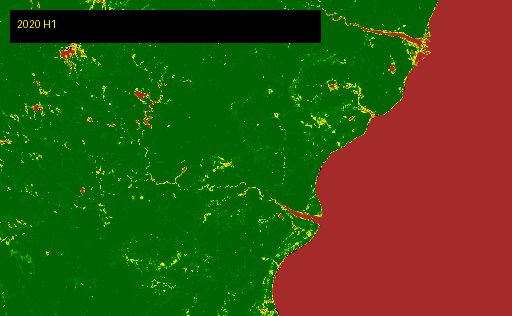

In [26]:
from IPython.display import Image, display

# 讀取並在 Code Cell 的輸出畫面中直接播放 GIF
display(Image(filename='taroko_ndvi_timelapse.gif'))

### Bonus 2 觀察紀錄：NDVI 動態時序動畫發現

透過本章節產出的 `taroko_ndvi_timelapse.gif` 動態時間序列動畫，簡短說明（50–100 字）：動畫中最明顯的三個變化時刻是什麼？

> *Answer:*2022年H2突然出現許多NDVI低值區域，有可能是當時有其他災害發生。2024年災害剛發生時大量原本NDVI高的區域出現破碎低值。此外2025-2026的崩塌位置可以發現植被恢復，所以不若剛崩塌時有許多NDVI低而呈黃色的斑塊。